<a href="https://colab.research.google.com/github/th900/Ciencia-de-dados-para-o-agronegocio/blob/main/Ci%C3%AAncia_de_dados_para_agronegocio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
import warnings

warnings.filterwarnings("ignore")

In [32]:
RAW_PATH = "/content/treino.csv"

df = pd.read_csv(RAW_PATH)
print("=" * 60)
print("1. DATASET CARREGADO")
print(f"   Shape: {df.shape}")
print("=" * 60)

1. DATASET CARREGADO
   Shape: (88858, 10)


In [31]:
df.head(10)

,Estimated_Insects_Count,Crop_Type,Soil_Type,Pesticide_Use_Category,Number_Doses_Week,Number_Weeks_Used,Number_Weeks_Quit,Season,Crop_Damage
0,188,1,0,1,0,0.0,0,1,0
1,209,1,0,1,0,0.0,0,2,1
2,257,1,0,1,0,0.0,0,2,1
3,257,1,1,1,0,0.0,0,2,1
4,342,1,0,1,0,0.0,0,2,1
5,448,0,1,1,0,NaN,0,2,1
6,448,0,1,1,0,NaN,0,2,1
7,577,1,0,1,0,0.0,0,1,2
8,731,0,0,1,0,0.0,0,2,0
9,1132,1,0,1,0,0.0,0,1,2


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88858 entries, 0 to 88857
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       88858 non-null  object 
 1   Estimated_Insects_Count  88858 non-null  int64  
 2   Crop_Type                88858 non-null  int64  
 3   Soil_Type                88858 non-null  int64  
 4   Pesticide_Use_Category   88858 non-null  int64  
 5   Number_Doses_Week        88858 non-null  int64  
 6   Number_Weeks_Used        79858 non-null  float64
 7   Number_Weeks_Quit        88858 non-null  int64  
 8   Season                   88858 non-null  int64  
 9   Crop_Damage              88858 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 6.8+ MB


In [9]:
df["Crop_Damage"].value_counts()

,count
Crop_Damage,
0,74238
1,12307
2,2313


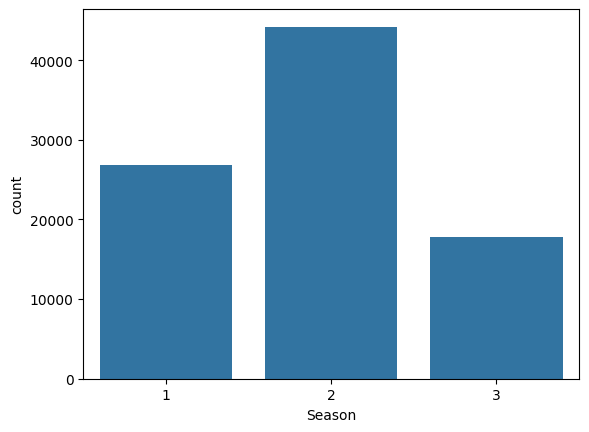

In [11]:
df['Season'].value_counts()
ax = sns.countplot(x=df['Season'])

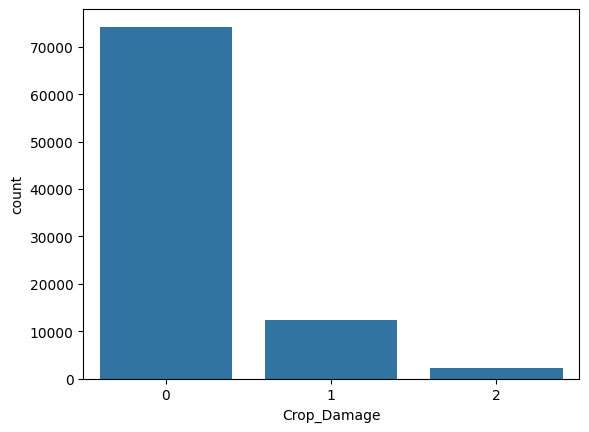

In [12]:
df['Crop_Damage'].value_counts()
ax = sns.countplot(x = df['Crop_Damage'])

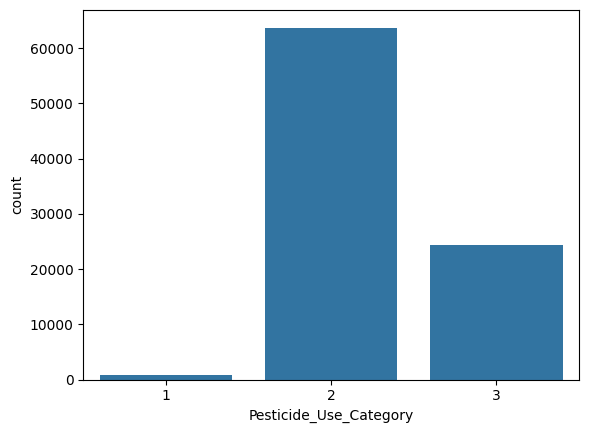

In [13]:
df['Pesticide_Use_Category'].value_counts()
ax = sns.countplot(x = df['Pesticide_Use_Category'])

In [20]:
df.isnull().sum()

,0
ID,0
Estimated_Insects_Count,0
Crop_Type,0
Soil_Type,0
Pesticide_Use_Category,0
Number_Doses_Week,0
Number_Weeks_Used,9000
Number_Weeks_Quit,0
Season,0
Crop_Damage,0


In [22]:
df.duplicated().sum()

np.int64(0)

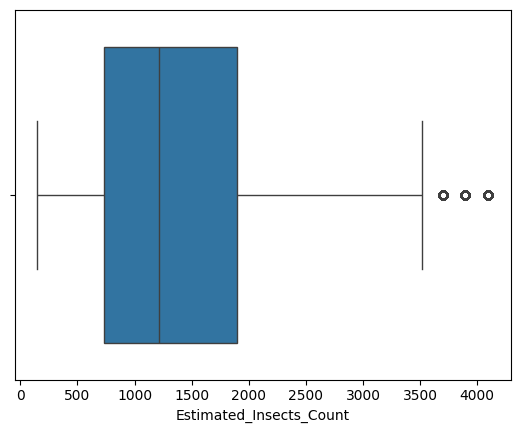

In [24]:
df['Estimated_Insects_Count'].describe()
ax= sns.boxplot( x = df['Estimated_Insects_Count'])

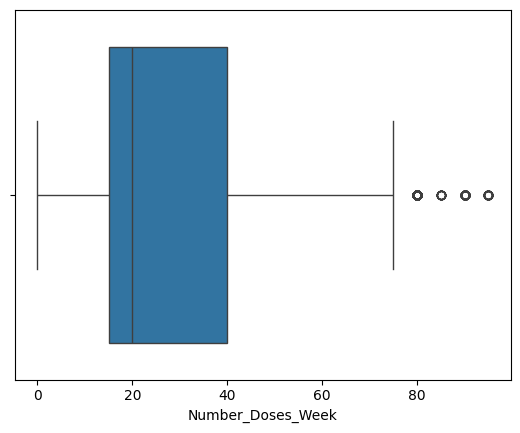

In [25]:
df['Number_Doses_Week'].describe()
ax = sns.boxplot(x = df['Number_Doses_Week'])

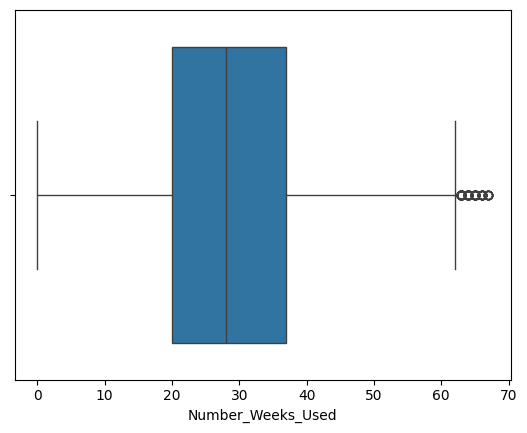

In [26]:
df['Number_Weeks_Used'].describe()
ax = sns.boxplot(x = df['Number_Weeks_Used'])

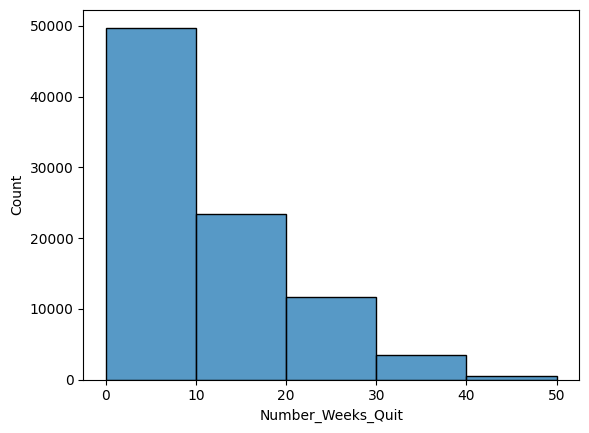

In [29]:
df['Number_Weeks_Quit'].describe()
ax = sns.histplot(x = df['Number_Weeks_Quit'], bins = 5)

In [34]:
df.dropna(inplace=True)

In [36]:
columns = df.columns

In [37]:
for col in ['Crop_Type', 'Soil_Type', 'Pesticide_Use_Category', 'Season']:
  df = pd.get_dummies(df, columns = [col])

In [33]:
df.drop(columns=["ID"], axis = 1, inplace=True)

In [41]:
df.head(4)

,Estimated_Insects_Count,Number_Doses_Week,Number_Weeks_Used,Number_Weeks_Quit,Crop_Damage,Crop_Type_0,Crop_Type_1,Soil_Type_0,Soil_Type_1,Pesticide_Use_Category_1,Pesticide_Use_Category_2,Pesticide_Use_Category_3,Season_1,Season_2,Season_3
0,188,0,0.0,0,0,False,True,True,False,True,False,False,True,False,False
1,209,0,0.0,0,1,False,True,True,False,True,False,False,False,True,False
2,257,0,0.0,0,1,False,True,True,False,True,False,False,False,True,False
3,257,0,0.0,0,1,False,True,False,True,True,False,False,False,True,False


In [42]:
X = df.drop(['Crop_Damage'], axis = 1)
y = df['Crop_Damage']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [48]:
model = CatBoostClassifier( n_estimators = 1000, max_depth = 4, random_state = 42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Learning rate set to 0.097814
0:	learn: 0.9826272	total: 44.4ms	remaining: 44.4s
1:	learn: 0.8956100	total: 89.4ms	remaining: 44.6s
2:	learn: 0.8256431	total: 131ms	remaining: 43.5s
3:	learn: 0.7684482	total: 172ms	remaining: 43s
4:	learn: 0.7220640	total: 226ms	remaining: 44.9s
5:	learn: 0.6827986	total: 283ms	remaining: 46.8s
6:	learn: 0.6504766	total: 340ms	remaining: 48.2s
7:	learn: 0.6226911	total: 386ms	remaining: 47.9s
8:	learn: 0.5994742	total: 450ms	remaining: 49.6s
9:	learn: 0.5785820	total: 497ms	remaining: 49.2s
10:	learn: 0.5612721	total: 525ms	remaining: 47.2s
11:	learn: 0.5459606	total: 563ms	remaining: 46.3s
12:	learn: 0.5325529	total: 596ms	remaining: 45.3s
13:	learn: 0.5207047	total: 635ms	remaining: 44.7s
14:	learn: 0.5102633	total: 693ms	remaining: 45.5s
15:	learn: 0.5012924	total: 726ms	remaining: 44.7s
16:	learn: 0.4940294	total: 747ms	remaining: 43.2s
17:	learn: 0.4875470	total: 767ms	remaining: 41.8s
18:	learn: 0.4813293	total: 789ms	remaining: 40.8s
19:	learn: 

In [52]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def report_metricas(y_test, y_pred):
    """
    Exibe as principais métricas de classificação para o dano da lavoura.
    """
    # Calculando as métricas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"--- Relatório de Performance ---")
    print(f"Acurácia:  {acc:.2%}")
    print(f"Precisão:  {prec:.2%}")
    print(f"Recall:    {rec:.2%}")
    print(f"F1-Score:  {f1:.2%}")
    print("-" * 30)

    # Matriz de Confusão para ver onde o modelo está errando (ex: trocando dano por praga por dano natural)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Matriz de Confusão')
    plt.ylabel('Real')
    plt.xlabel('Previsto')
    plt.show()




--- Relatório de Performance ---
Acurácia:  84.91%
Precisão:  80.15%
Recall:    84.91%
F1-Score:  80.98%
------------------------------


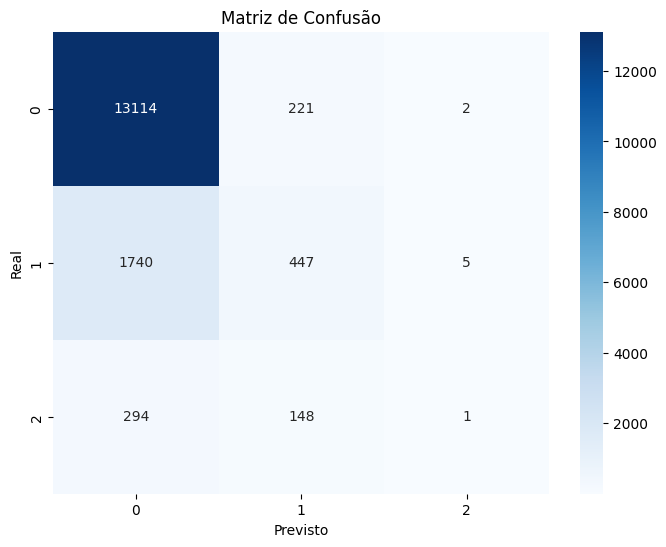

In [54]:
report_metricas(y_test, y_pred)